# Базовая модель прогнозирования(Statsforecast)

Сегодня мы попробуем построить наш первый пайплайн прогнозированяи временных рядов при помощи библиотеки [Statsforecast](https://github.com/Nixtla/statsforecast). 

### План семинара 
1. Формат данных
2. `StatsForecast` -- интерфейс для обучения/валидации/инференса
3. Кросcвалидация


In [1]:
import logging
import warnings

warnings.filterwarnings('ignore')
logging.getLogger('statsforecast').setLevel(logging.ERROR)

# 1. Загрузка данных

Формат данных long(где-то мы уже это видели):
- `"unique_id"` -- уникальный айдишник ряда
- `"ds"` -- временная метка
- `"y"` -- значение временного ряда

Могут быть и другие колонки с дополнительными данными(_упражнение для читателя_)

Тут **нет специального контейнера** для работы с данныхми -- все операции с данными на вашей совести

## 1.1 Чтение

In [2]:
import pandas as pd
import polars as pl # Есть поддержка polars, интерфейс принимает произвольный датафрэйм

In [3]:
Y_df = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/data/nordic_merch_sales.csv")
Y_df = Y_df.rename(columns={
    "segment": "unique_id",
    "timestamp": "ds",
    "target": "y"
})
Y_df["ds"] = pd.to_datetime(Y_df["ds"]) 

Y_df.head()

,ds,y,unique_id
0,2015-01-01,329,Finland_KaggleMart_Kaggle Mug
1,2015-01-01,520,Finland_KaggleMart_Kaggle Hat
2,2015-01-01,146,Finland_KaggleMart_Kaggle Sticker
3,2015-01-01,572,Finland_KaggleRama_Kaggle Mug
4,2015-01-01,911,Finland_KaggleRama_Kaggle Hat


In [4]:
Y_df_pl = pl.from_pandas(Y_df)
Y_df_pl.head()

ds,y,unique_id
datetime[ns],i64,str
2015-01-01 00:00:00,329,"""Finland_KaggleMart_Kaggle Mug"""
2015-01-01 00:00:00,520,"""Finland_KaggleMart_Kaggle Hat"""
2015-01-01 00:00:00,146,"""Finland_KaggleMart_Kaggle Stic…"
2015-01-01 00:00:00,572,"""Finland_KaggleRama_Kaggle Mug"""
2015-01-01 00:00:00,911,"""Finland_KaggleRama_Kaggle Hat"""


## 1.2 Картиночка

In [5]:
from statsforecast import StatsForecast

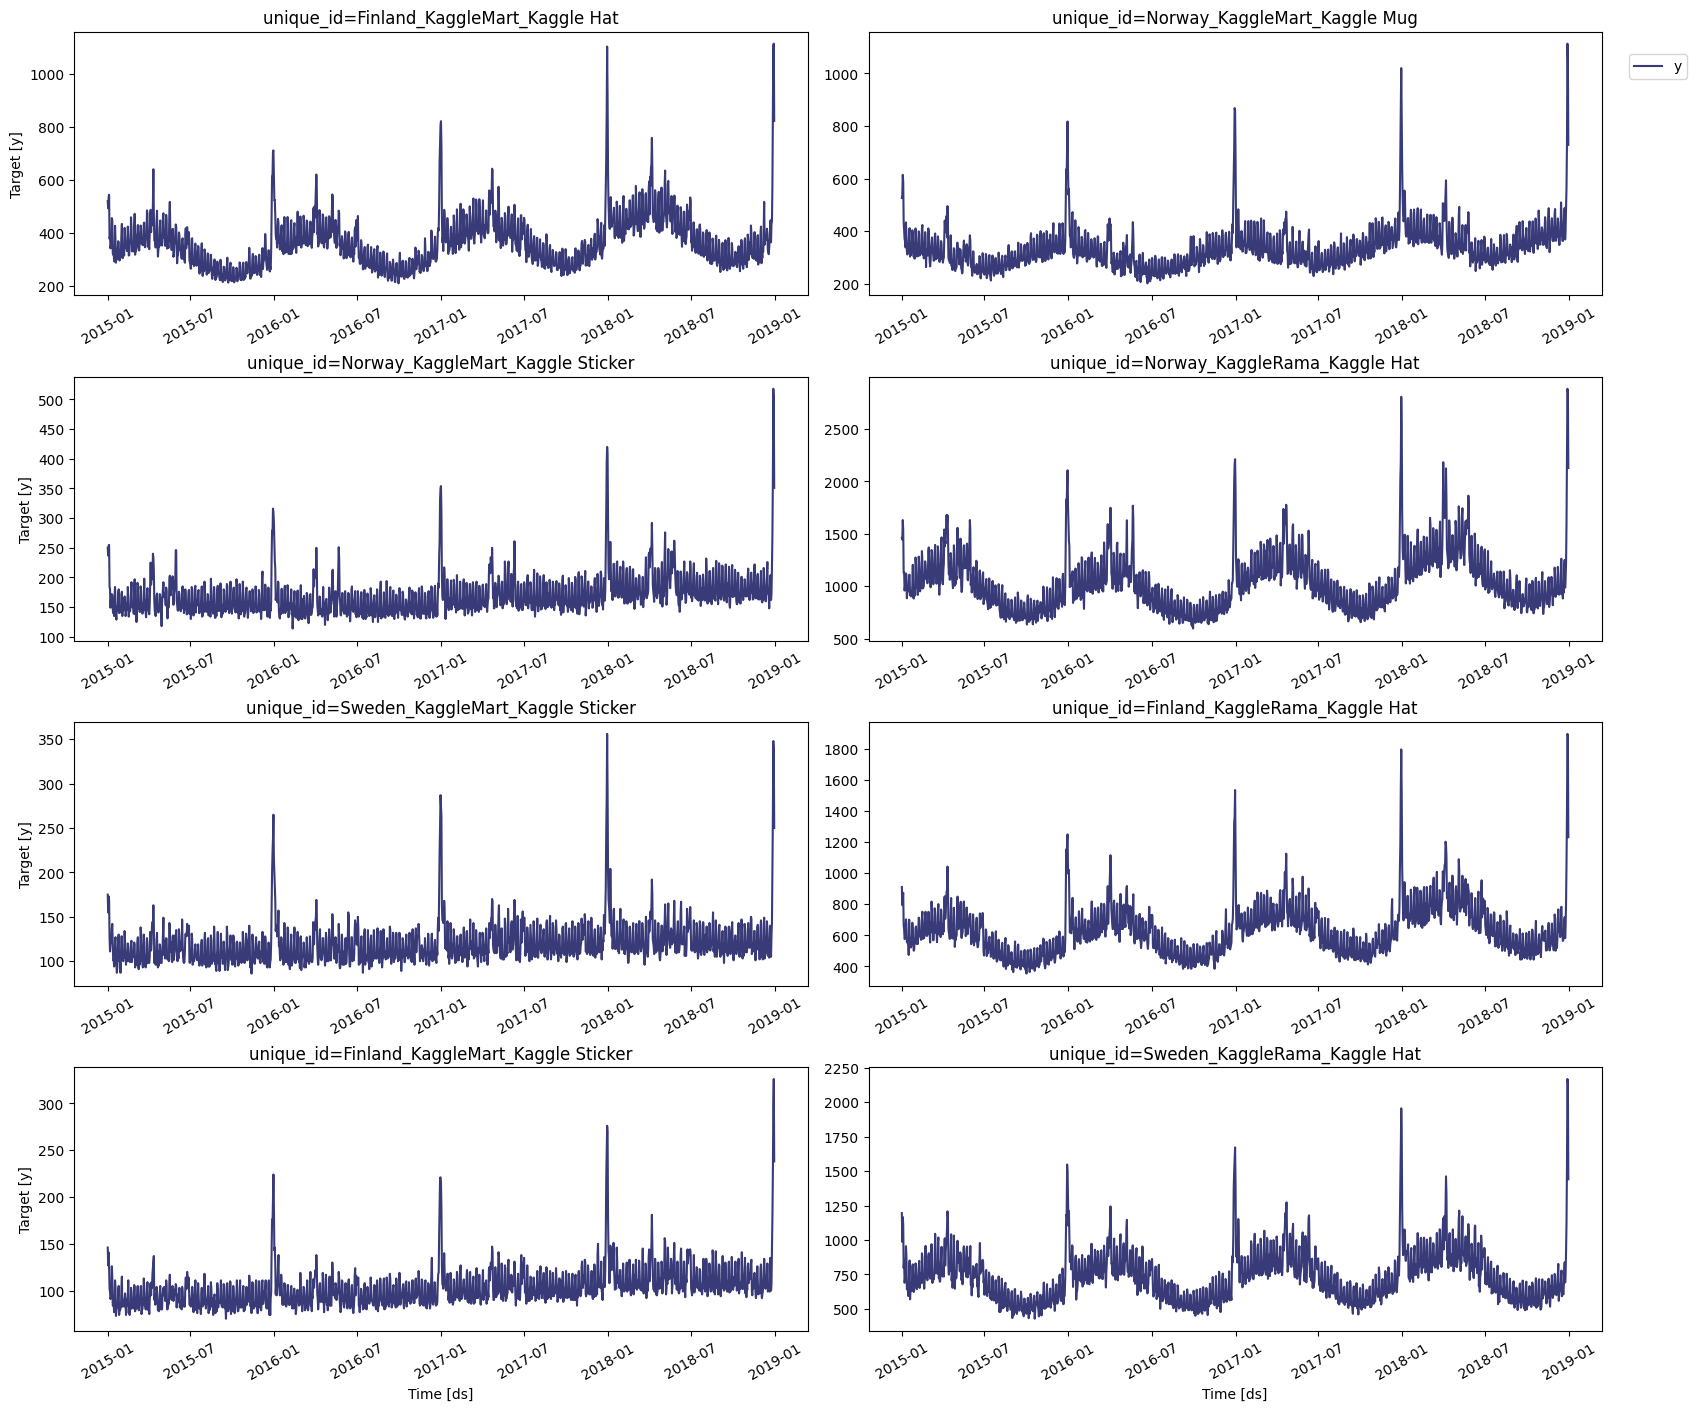

In [6]:
StatsForecast.plot(Y_df) # Pandas

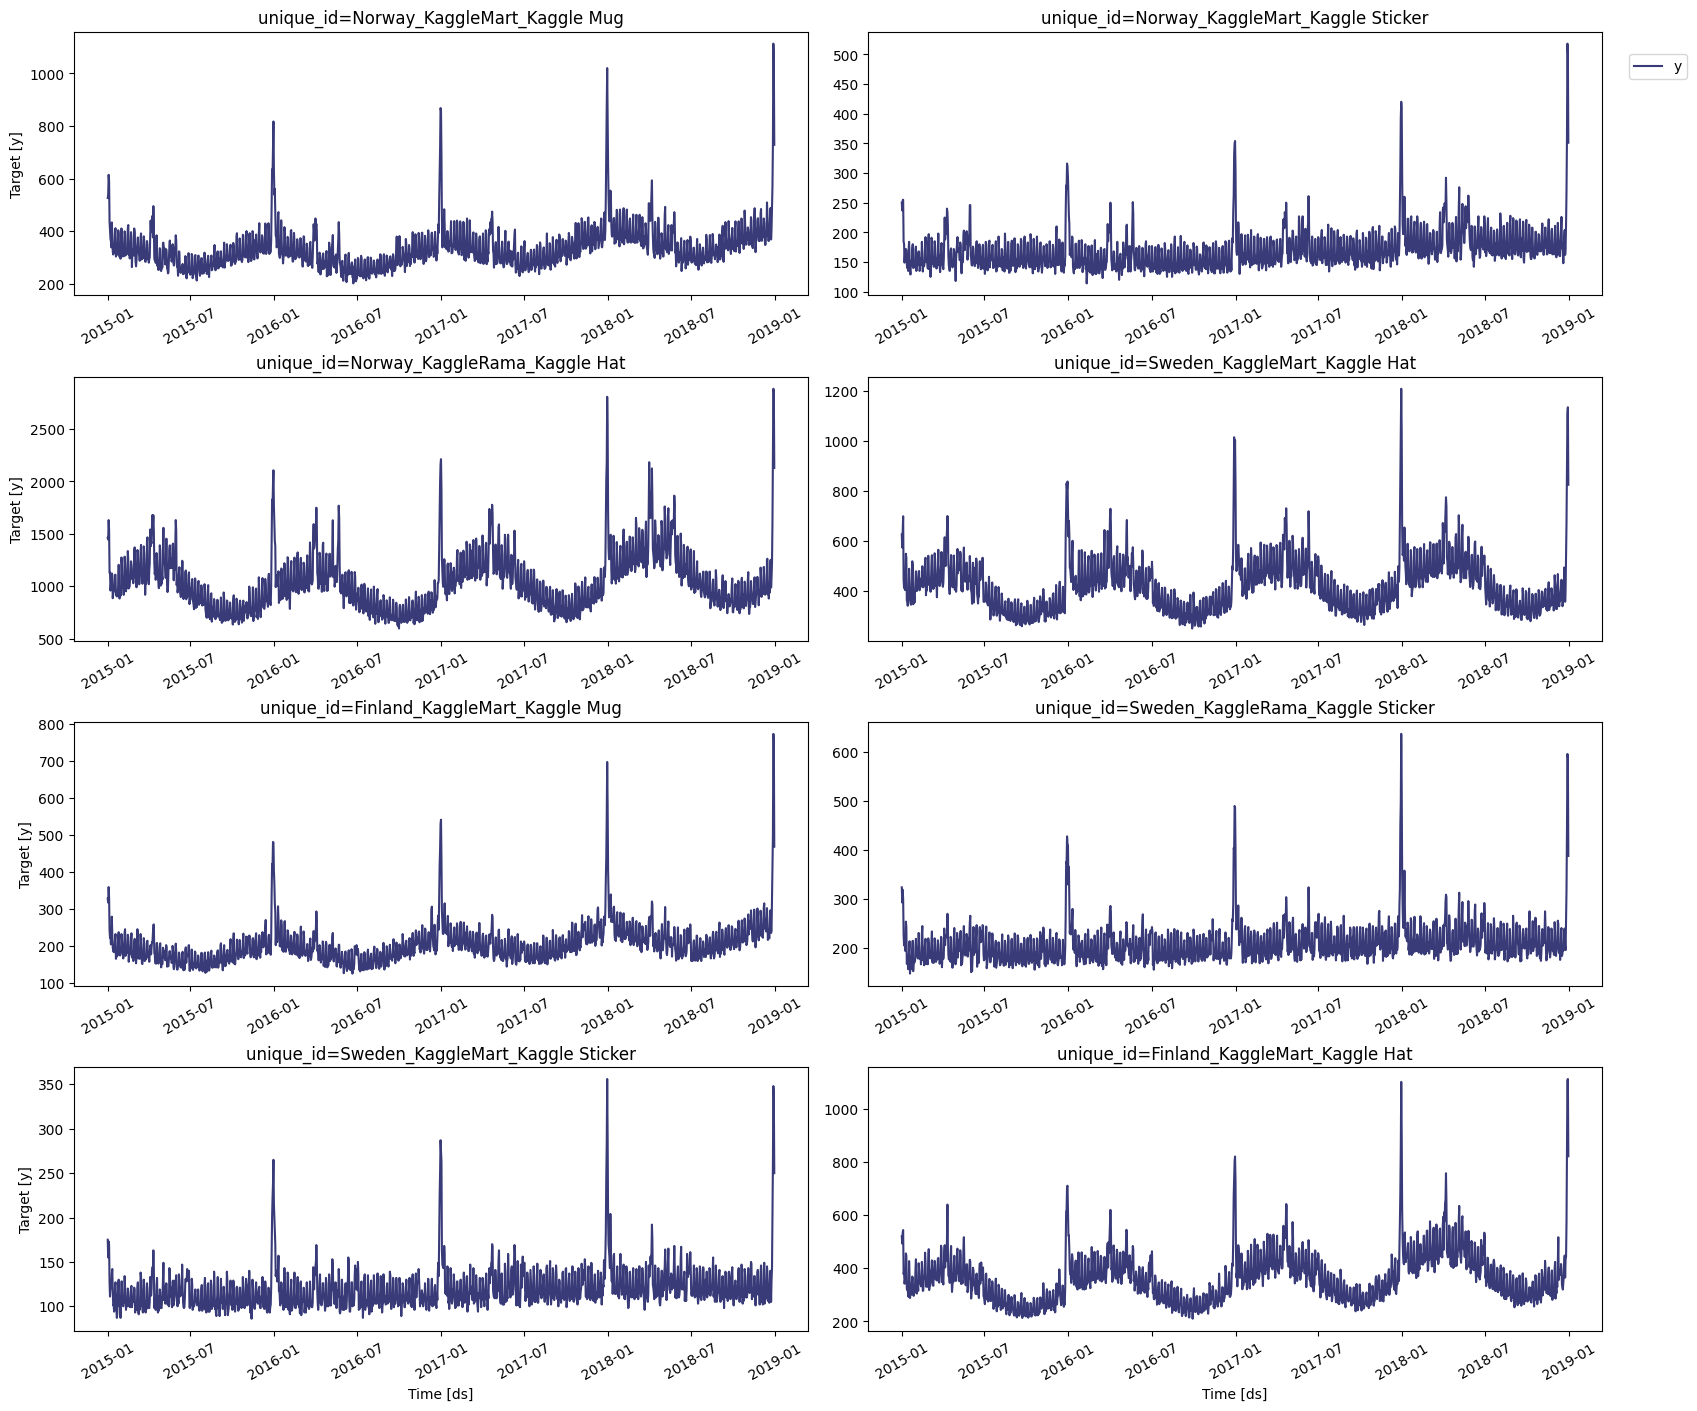

In [7]:
StatsForecast.plot(Y_df_pl) # Polars

Далее будем работать с pandas, суть ясна -- все методы интерфейса поддерживают оба контейнера

# 2. StatsForecast -- интерфейс моделей

Тут семейство моделей SMA представлено следующим образом

In [8]:
from statsforecast.models import (
    Naive, # Последняя известная точка   
    SeasonalNaive, # Сезонная последня известная точка (лаг s)
    HistoricAverage, # Среднее за всю историю ряда (константа)
    WindowAverage, # Среднее в окне    
    SeasonalWindowAverage, # Сезонное среднее в окне (последние s понедельников)
)

seasonal_length = 7
horizon = 365

## 2.1 Как построить прогноз

В этой библиотеке есть возможность задать целый список моделей

In [9]:
models = [
    Naive(),
    SeasonalNaive(season_length=365),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalWindowAverage(window_size=3, season_length=seasonal_length)
]

Для работы с моделями **рекомендуется** использовать интерфейс StatsForecast (аля Pipeline)

In [10]:
sf = StatsForecast( 
    models=models, # Какие модели обучаем
    freq="D", 
    fallback_model = Naive(), # Модель для кейсов, где остальные сломались
    n_jobs=-1, # По рядам
    verbose=True
)

Строим прогнозы без сохранения обученных моделей(сейчас нам такое не нужно, нам особо нечего сохранять)

In [11]:
forecasts_df = sf.forecast(
    df=Y_df, # Данные для обучения
    h=horizon, # Горизонт прогнозирования
    level=[90] # Предсказательные интервалы
)
forecasts_df.head()

Forecast: 100%|███████████████████████████████████████████| 18/18 [Elapsed: 00:10]


,unique_id,ds,Naive,Naive-lo-90,Naive-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,WindowAverage,WindowAverage-lo-90,WindowAverage-hi-90,SeasWA,SeasWA-lo-90,SeasWA-hi-90
0,Finland_KaggleMart_Kaggle Hat,2019-01-01,822.0,733.632141,910.367859,621.0,512.088379,729.911621,362.479797,202.025421,522.934143,822.0,733.632141,910.367859,822.0,733.632141,910.367859
1,Finland_KaggleMart_Kaggle Hat,2019-01-02,822.0,697.028931,946.971069,512.0,403.088348,620.911621,362.479797,202.025421,522.934143,822.0,697.028931,946.971069,822.0,697.028931,946.971069
2,Finland_KaggleMart_Kaggle Hat,2019-01-03,822.0,668.942383,975.057617,449.0,340.088348,557.911621,362.479797,202.025421,522.934143,822.0,668.942383,975.057617,822.0,668.942383,975.057617
3,Finland_KaggleMart_Kaggle Hat,2019-01-04,822.0,645.264282,998.735718,420.0,311.088348,528.911621,362.479797,202.025421,522.934143,822.0,645.264282,998.735718,822.0,645.264282,998.735718
4,Finland_KaggleMart_Kaggle Hat,2019-01-05,822.0,624.403442,1019.596558,415.0,306.088348,523.911621,362.479797,202.025421,522.934143,822.0,624.403442,1019.596558,822.0,624.403442,1019.596558


## 2.2 Визуализируем прогноз

Дефолтный вариант

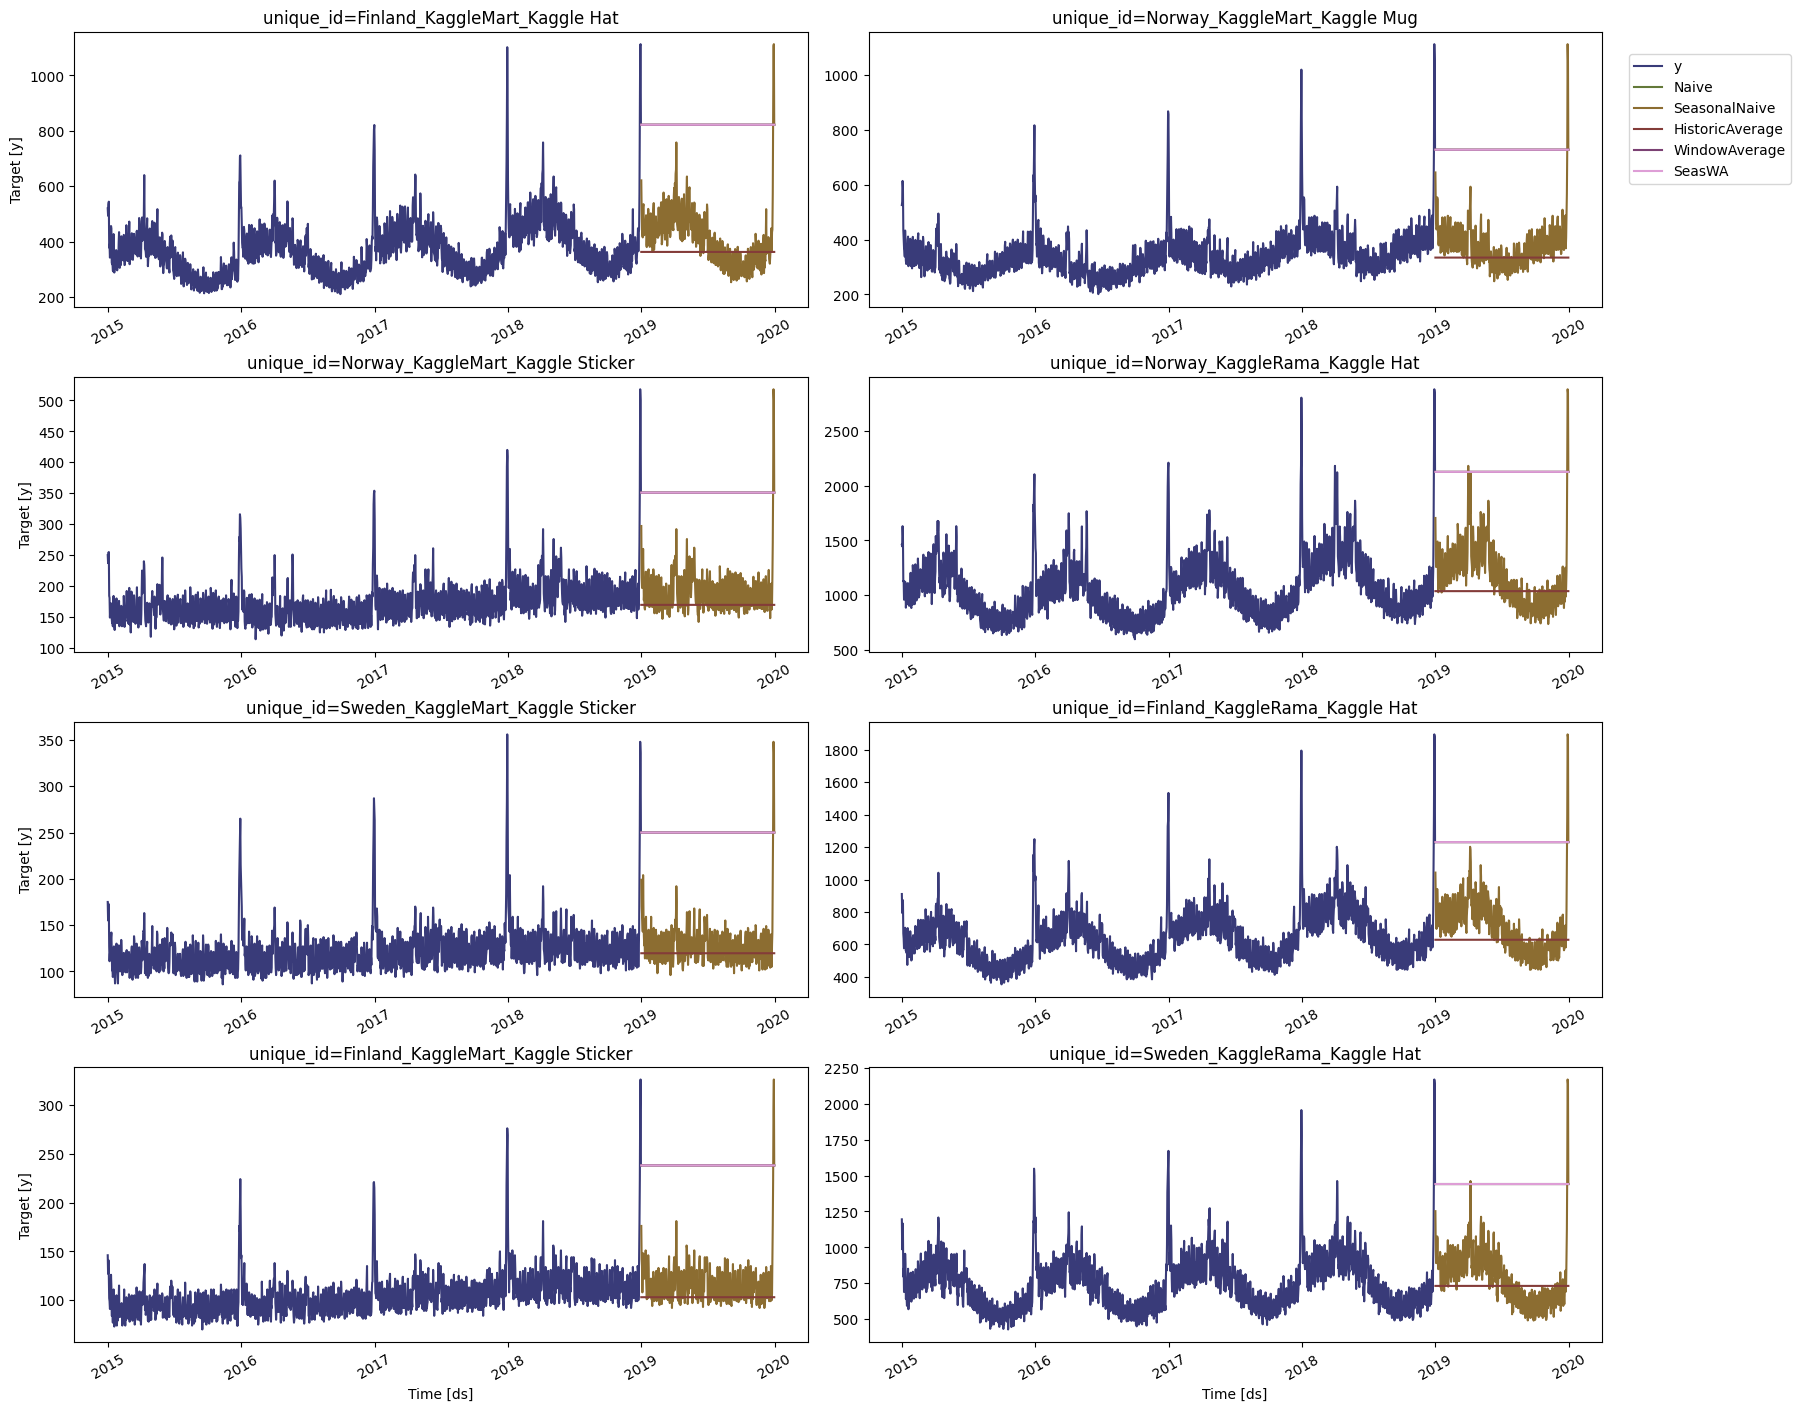

In [12]:
sf.plot(Y_df, forecasts_df)

Можно накрутить всяких кастомизаций

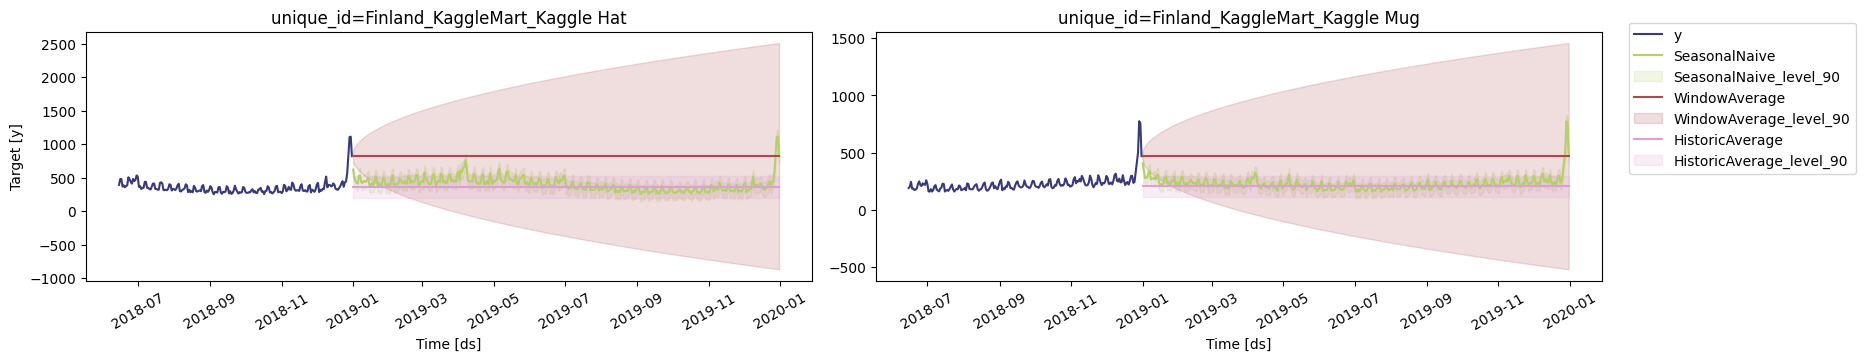

In [13]:
sf.plot(
    Y_df, forecasts_df,
    max_insample_length=200, # Длина истории
    models=["SeasonalNaive","WindowAverage", "HistoricAverage"], # Какие модели
    unique_ids=["Finland_KaggleMart_Kaggle Hat", "Finland_KaggleMart_Kaggle Mug"], # Какие ряды
    level=[90] # Предсказательные интервалы
)

# 3. Кросс-валидация

Чтобы оценить качество на кросс-валидации нужно прделать вот такие шаги руками
1. `cross_validation` -- получить прогнозы на тестовых фолдах
2. `evaluate_cv` -- замерить метрики

![](https://raw.githubusercontent.com/Nixtla/statsforecast/main/nbs/imgs/ChainedWindows.gif)

## 3.1 Исторические прогнозы

Для каждой модели получаем исторические прогнозы для каждого фолда

In [14]:
cv_df = sf.cross_validation(
    df=Y_df,
    h=horizon, # Горизонт прогнозирования
    step_size=horizon, # Сдвиг между фолдами
    n_windows=3 # Количество фолдов
)

Cross Validation Time Series 1: 100%|██████████| 3/3 [00:00<00:00, 7354.13it/s]


In [15]:
cv_df.head() # cutoff -- откуда стартовали предсказания

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,HistoricAverage,WindowAverage,SeasWA
0,Finland_KaggleMart_Kaggle Hat,2016-01-02,2016-01-01,524.0,523.0,493.0,329.478149,610.571411,403.666656
1,Finland_KaggleMart_Kaggle Hat,2016-01-03,2016-01-01,469.0,523.0,535.0,329.478149,610.571411,437.000000
2,Finland_KaggleMart_Kaggle Hat,2016-01-04,2016-01-01,395.0,523.0,544.0,329.478149,610.571411,394.333344
3,Finland_KaggleMart_Kaggle Hat,2016-01-05,2016-01-01,378.0,523.0,378.0,329.478149,610.571411,413.666656
4,Finland_KaggleMart_Kaggle Hat,2016-01-06,2016-01-01,379.0,523.0,389.0,329.478149,610.571411,414.666656


## 3.2 Замер метрик

Оцениваем качество с усреденнием по всем точкам -- если хотим более сложную логику, нужно реализовывать руками

In [16]:
from utilsforecast.losses import mae, smape

In [17]:
mae(cv_df, models=["Naive", "SeasonalNaive"])

,unique_id,Naive,SeasonalNaive
0,Finland_KaggleMart_Kaggle Hat,380.706848,49.378994
1,Finland_KaggleMart_Kaggle Mug,289.020996,27.835617
2,Finland_KaggleMart_Kaggle Sticker,103.782646,13.887671
3,Finland_KaggleRama_Kaggle Hat,704.513245,85.894974
4,Finland_KaggleRama_Kaggle Mug,460.393616,47.992695
5,Finland_KaggleRama_Kaggle Sticker,196.515976,24.383562
6,Norway_KaggleMart_Kaggle Hat,584.733337,85.148857
7,Norway_KaggleMart_Kaggle Mug,404.966217,48.358906
8,Norway_KaggleMart_Kaggle Sticker,170.740646,23.705936
9,Norway_KaggleRama_Kaggle Hat,1059.369873,148.326935


Например можем определить лучшую модель для каждого ряда в отельности

In [18]:
def evaluate_cv(df, metric):
    models = df.columns.drop(['unique_id', 'ds', 'y', 'cutoff']).tolist()
    evals = metric(df, models=models)
    evals['best_model'] = evals[models].idxmin(axis=1)
    evals['best_metric'] = evals[models].min(axis=1)
    return evals

In [19]:
evaluation_df = evaluate_cv(cv_df, smape)
evaluation_df.head()

,unique_id,Naive,SeasonalNaive,HistoricAverage,WindowAverage,SeasWA,best_model,best_metric
0,Finland_KaggleMart_Kaggle Hat,0.333450,0.065856,0.095303,0.281364,0.118520,SeasonalNaive,0.065856
1,Finland_KaggleMart_Kaggle Mug,0.405875,0.066948,0.078510,0.349225,0.175582,SeasonalNaive,0.066948
2,Finland_KaggleMart_Kaggle Sticker,0.317146,0.066310,0.062695,0.279748,0.107005,HistoricAverage,0.062695
3,Finland_KaggleRama_Kaggle Hat,0.351783,0.066068,0.093592,0.281454,0.117750,SeasonalNaive,0.066068
4,Finland_KaggleRama_Kaggle Mug,0.384546,0.066174,0.078880,0.344867,0.172543,SeasonalNaive,0.066174


In [20]:
evaluation_df["best_metric"].mean()

0.063982114

Посмотрим на количество побед для каждой модели -- оказывается для разных радов, выигрывают разные модели(сюрприз сюрприз)

In [21]:
evaluation_df['best_model'].value_counts().to_frame().reset_index()

,best_model,count
0,SeasonalNaive,12
1,HistoricAverage,6


## 3.3 Картинка
Нарисуем истроические прогнозы VS факт

In [22]:
def plot_cv(df, cv_df, **kwargs):
    from IPython.display import display
    
    cv_df = cv_df.copy()
    cv_df.rename(columns = {'y' : 'actual'}, inplace = True)
    cutoff = cv_df['cutoff'].unique()
    for k in range(len(cutoff)): 
        cv = cv_df[cv_df['cutoff'] == cutoff[k]]
        display(StatsForecast.plot(df, cv.loc[:, cv.columns != 'cutoff'], **kwargs))

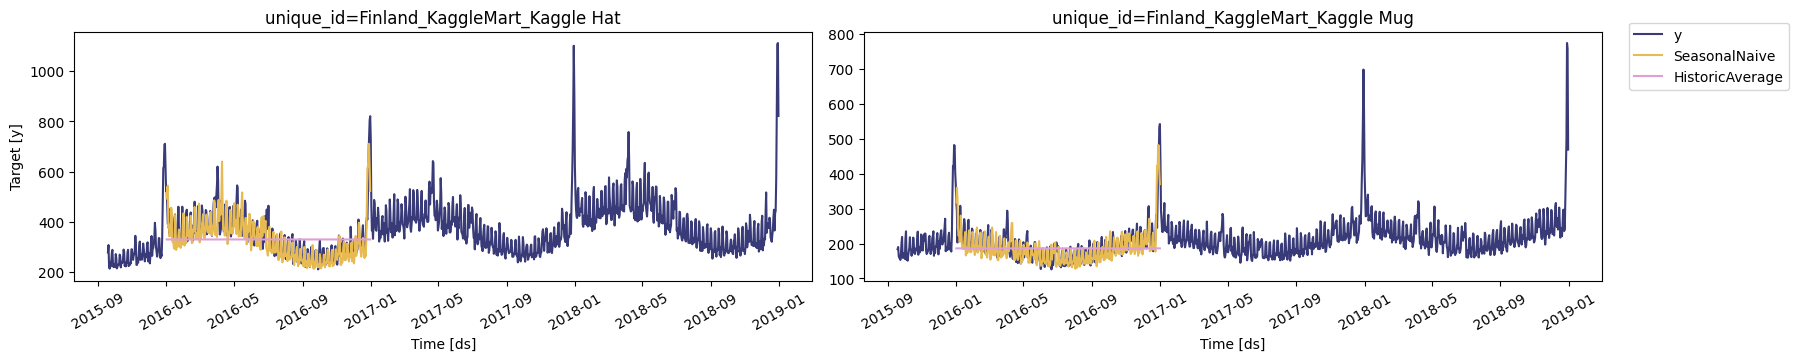

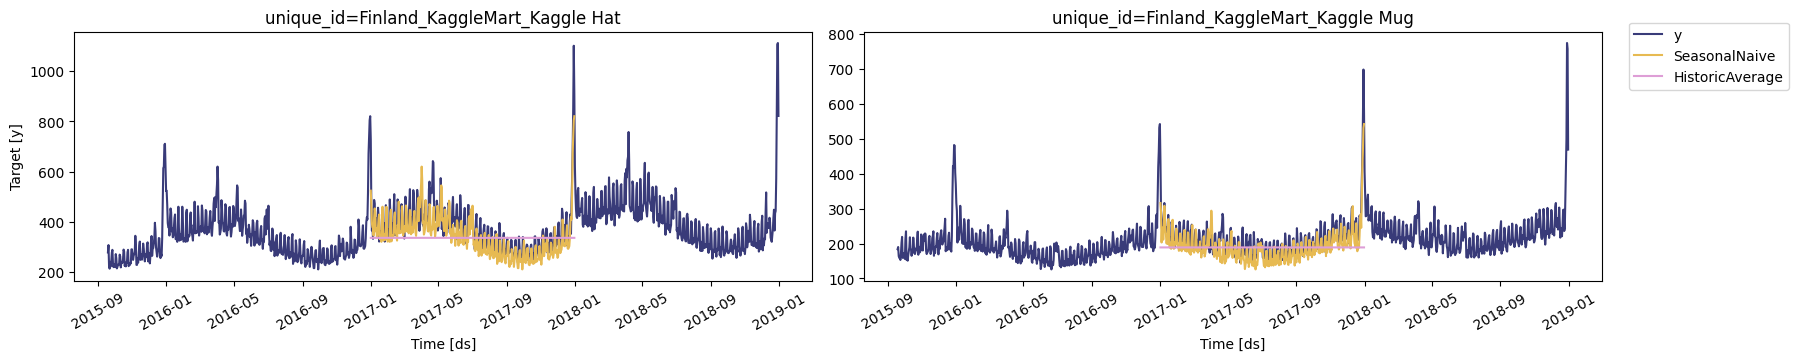

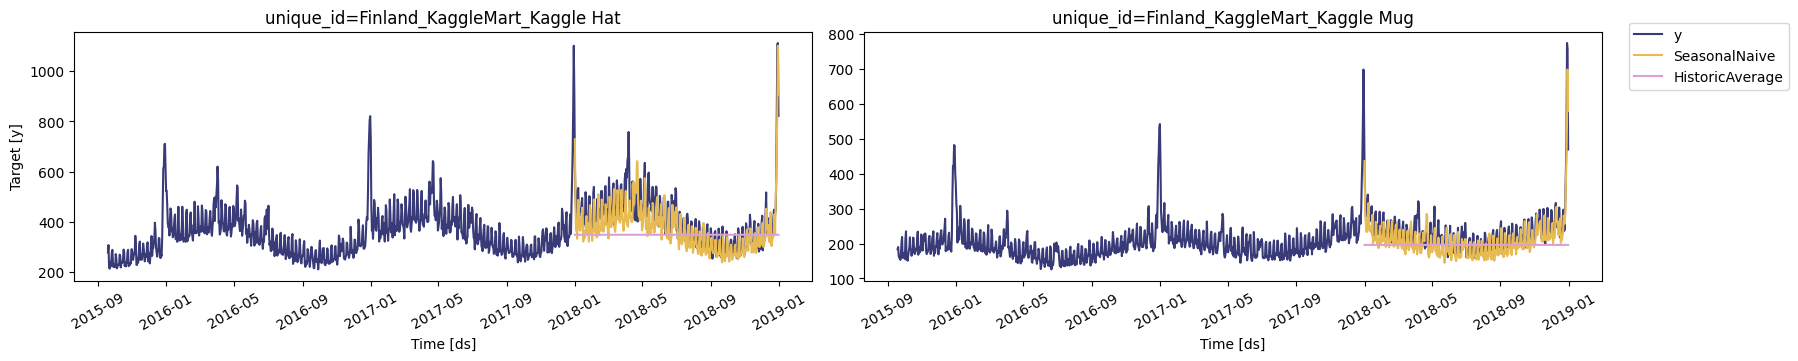

In [23]:
plot_cv(
    Y_df, cv_df,
    max_insample_length=1200,
    unique_ids=["Finland_KaggleMart_Kaggle Hat", "Finland_KaggleMart_Kaggle Mug"],
    models=["SeasonalNaive", "HistoricAverage"]
)